# <a id="#">Task 3 – Mean, median, and Gaussian filtering</a>

In [3]:
import numpy
import matplotlib.pyplot as plt

---

## Linear filtering by convolution (mean filter)

**<a id="#">Task 3.1.1.</a>** Load the image `data/astronaut.png` and show it:

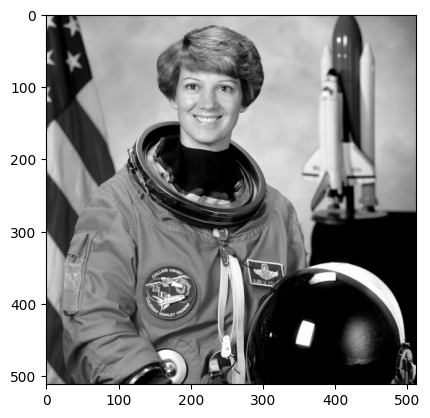

In [4]:
img = plt.imread('data/astronaut.png')
plt.imshow(img, 'gray')

**<a id="#">Task 3.1.2.</a>** Implement a mean filter:

In [5]:

def meanfilter(img_in, size): #Es hilft es auf einem blatt papier durchzuspielen. Für ein p im bild img_in werden in z.B. einem drei mal drei feld mithilfe filterquadrats alle Pixelintensitäten aufsummiert und durch die anzahl der summierten pixelintensitäten dividiert. dieser Mittelwert wird an die entsprechende position, in einem bild, das bisher nur mit Nullen gefüllt ist, eingesetzt. Durch das if statement wird gecheckt, dass tatsächlich auch pixel innerhalb des bildes verwebdet werden, aber trotzdem für randpixel mittelwerte berechnet werden, halt mit einer kleineren anzahl an pixeln (das betrifft das if statement mit #). Das neue if statement bezweckt, dass nur für Pixel der mittelwert berechnet wird, für die die neighborhodd vollständig im bild liegt. für pixel bei denen das nicht der fall ist, wird einfach ihr wert unverändert eingesetzt.
    result = numpy.zeros(img_in.shape)
    n = (size - 1) // 2
    for p in numpy.ndindex(img_in.shape): #p ist einfach etwas für das zuerst (0,0) gesetzt wird, dann (0,1) usw. Entsprechend der iterable numpy.ndindex(img_in.shape). Aber: img_in.shape liefert eine absolute anzahl an reihen und spalten! D.h. p wird wie folgt hochgezählt: Von (0,0) bis (anzahl an zeilen-1, anzahl an spalten-1)
        neighborhood_sum = 0
        count = 0

        if (p[0] - n < 0 or p[0] + n >= img_in.shape[0] or
            p[1] - n < 0 or p[1] + n >= img_in.shape[1]):
            continue

        for q in numpy.ndindex(size, size): #wenn ich also size = 5 wähle wird auch nur bis (4,4) hochgezählt
            i = p[0] + q[0] - n
            j = p[1] + q[1] - n

            #if 0 <= i < img_in.shape[0] and 0 <= j < img_in.shape[1]:
            neighborhood_sum += img_in[i, j]
            count += 1

        result[p] = neighborhood_sum / count
    return result



**<a id="#">Task 3.1.3.</a>** Test your implementation from above by using the function `meanfilter` for the previously loaded image and show the result:

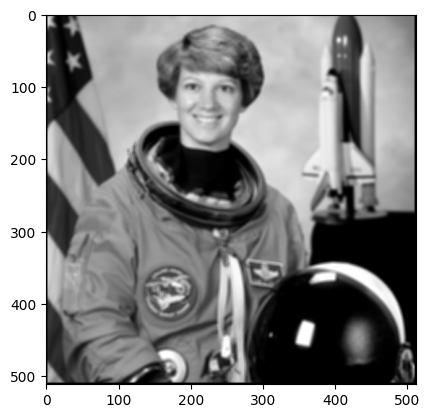

In [6]:
fimg= meanfilter(img, 5)
plt.imshow(fimg, 'gray')

**<a id="#">Task 3.1.4.</a>** Compare your result for filter size `5` with the correct result image `data/astronaut_meanfilter5.png`:

In [7]:
cimg = plt.imread('data/astronaut_meanfilter5.png')
assert numpy.allclose(fimg, cimg, atol = 1/255) #da der code ausgeführt werden kann, ist der vergleich richtig, also die bilder sind gleich

---

## Non-linear filtering

**<a id="#">Task 3.2.1.</a>** Implement a median filter:

In [8]:
def medianfilter(img_in, size):
    result = numpy.zeros(img_in.shape)
    n = (size - 1) // 2
    for p in numpy.ndindex(img_in.shape):
        if (p[0] - n < 0 or p[0] + n >= img_in.shape[0] or
            p[1] - n < 0 or p[1] + n >= img_in.shape[1]):
            continue
        a = list()

        for q in numpy.ndindex(size, size):
            i = p[0] + q[0] - n
            j = p[1] + q[1] - n
            a.append(img_in[i, j])

        a.sort()
        result[p] = numpy.median(a)
        #result[p] = a[(len(a) // 2) + 1] Das war wohl falsch
    return result

**<a id="#">Task 3.2.2.</a>** First, test your implementation from above by using the function `medianfilter` for the previously loaded image and show the result:

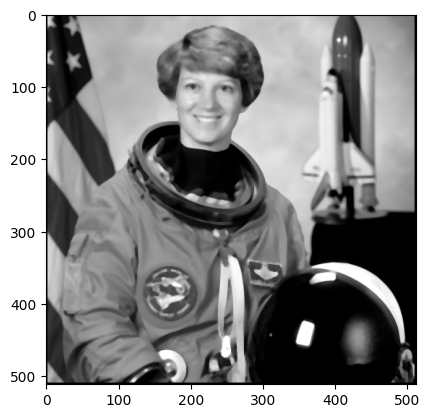

In [9]:
img2 = medianfilter(img, 5)
plt.imshow(img2, 'gray')

Then, compare your result for filter size `5` with the correct result image `data/astronaut_medianfilter5.png`:

In [10]:
img3 = plt.imread('data/astronaut_medianfilter5.png')
assert numpy.allclose(img2, img3, atol = 1/255)

---

## Using pre-implemented filters

**<a id="#">Task 3.3.1.</a>** Load the package `scipy.ndimage`:

In [1]:
import scipy.ndimage

**<a id="#">Task 3.3.2 (a).</a>** Apply a **mean filter** from `scipy.ndimage` to the loaded image:

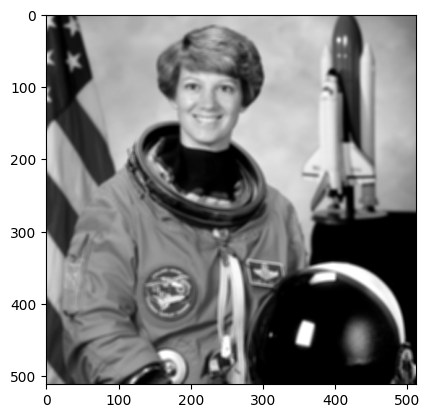

In [11]:
scipy.ndimage.uniform_filter(img, 5)
plt.imshow(scipy.ndimage.uniform_filter(img, 5), 'gray')

**<a id="#">Task 3.3.2 (b).</a>** Apply a **median filter** from `scipy.ndimage` to the loaded image:

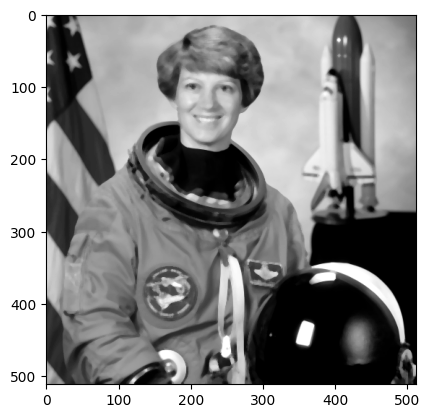

In [12]:
plt.imshow(scipy.ndimage.median_filter(img, 5), 'gray')

**<a id="#">Task 3.3.2 (c).</a>** Apply a **Gaussian filter** from `scipy.ndimage` to the loaded image:

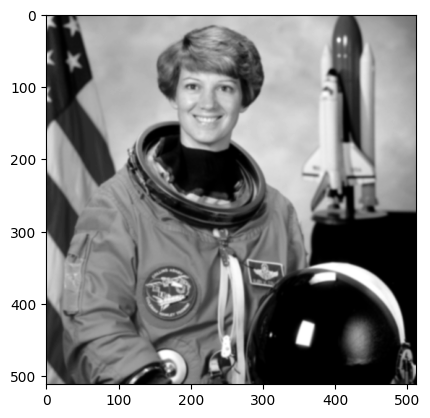

In [16]:
plt.imshow(scipy.ndimage.gaussian_filter(img, 1), 'gray')

**<a id="#">Task 3.3.3.</a>** Compare the results obtained using the functions from `scipy.ndimage` with those you obtained using your own implementations. What are the main differences? Do you have an explanation?

---

## Slicing and benchmarking

**<a id="#">Task 3.4.2.</a>** Implement either a mean filter or a median filter using only a single `for`-loop:

In [ ]:
def fastfilter(img_in, size):
    ...

**<a id="#">Task 3.4.3.</a>** First, test your implementation from above by using the function `fastfilter` for the previously loaded image and show the result:

Then, compare your result to those obtained using your implementation for either `meanfilter` or `medianfilter`, respectively:

**<a id="#">Task 3.4.4.</a>** Benchmark the code run times:

**<a id="#">Task 3.4.5.</a>** Document your observations regarding the benchmarking results and try to think of an explanation: